### 1.1 : Préparer les bibliothèques et les chemins

L'objectif est d'explorer le dataset image afin de récupérer les caractéristiques
principales de chaque fichier.

Pour chaque image, nous allons relever :

- son nom ;
- sa classe ;
- son format ;
- son mode ;
- sa largeur et sa hauteur ;
- l'écart-type de ses pixels ;
- son nombre de canaux ;
- sa taille en octets.

Les fichiers corrompus seront également pris en compte afin qu'ils ne bloquent
pas l'exploration du dataset.

In [1]:
%pip install tensorflow pandas numpy matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError


RAW_DIR = Path("../data/raw")

CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash",
]

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif",
    ".webp",
    ".tif",
    ".tiff",
}

In [3]:
#verif 

print(f"Dossier du dataset : {RAW_DIR}")
print(f"Classes : {CLASSES}")

Dossier du dataset : ..\data\raw
Classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


### 1.2 : Fonction d'analyse d'une image

La fonction `analyser_image()` inspecte une image sans la modifier.

Elle récupère ses métadonnées et calcule l'écart-type des pixels.

Si l'image est corrompue ou illisible, la fonction retourne tout de même
les informations disponibles et indique que l'image est corrompue.

In [4]:
def analyser_image(image_path, classe):
    """Analyse une image et retourne ses caractéristiques."""
    
    taille_octets = image_path.stat().st_size

    resultat = {
        "nom": image_path.name,
        "classe": classe,
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "ecart_type_pixels": None,
        "nombre_canaux": None,
        "taille_octets": taille_octets,
        "corrompue": False,
    }

    try:
        # premiere ouverture pour verifier l'integrite du fichier
        with Image.open(image_path) as image:

            # verifier si l'image est exploitable
            image.verify()

        # deuxieme ouverture pour acceder reellement aux pixels
        with Image.open(image_path) as image:
            resultat["format"] = image.format
            resultat["mode"] = image.mode
            resultat["largeur"], resultat["hauteur"] = image.size

            pixels = np.asarray(image)

            if pixels.ndim == 2:
                resultat["nombre_canaux"] = 1
            elif pixels.ndim == 3:
                resultat["nombre_canaux"] = pixels.shape[2]

            resultat["ecart_type_pixels"] = float(pixels.std())

    except (UnidentifiedImageError, OSError, SyntaxError):
        resultat["corrompue"] = True

    return resultat

### 1.3 : Parcourir tout le dataset

Le dataset est parcouru classe par classe.

Chaque image est analysée individuellement et son résultat est ajouté à une
liste qui sera ensuite transformée en DataFrame Pandas.

In [5]:
resultats = []

for classe in CLASSES:
    dossier_classe = RAW_DIR / classe

    for image_path in sorted(dossier_classe.iterdir()):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            resultat = analyser_image(image_path, classe)
            resultats.append(resultat)

df_images = pd.DataFrame(resultats)

df_images.head()

,nom,classe,format,mode,largeur,hauteur,ecart_type_pixels,nombre_canaux,taille_octets,corrompue
0,cardboard1.jpg,cardboard,JPEG,RGB,512.0,384.0,40.588529,3.0,17333,False
1,cardboard10.jpg,cardboard,JPEG,RGB,512.0,384.0,42.571288,3.0,21683,False
2,cardboard100.jpg,cardboard,JPEG,RGB,512.0,384.0,46.108305,3.0,14884,False
3,cardboard101.jpg,cardboard,JPEG,RGB,512.0,384.0,72.263996,3.0,14289,False
4,cardboard102.jpg,cardboard,JPEG,RGB,512.0,384.0,48.388937,3.0,18015,False


In [6]:
#verif

print(f"Nombre total de fichiers analysés : {len(df_images)}")

df_images.info()

Nombre total de fichiers analysés : 1032
<class 'pandas.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nom                1032 non-null   str    
 1   classe             1032 non-null   str    
 2   format             1026 non-null   str    
 3   mode               1026 non-null   str    
 4   largeur            1026 non-null   float64
 5   hauteur            1026 non-null   float64
 6   ecart_type_pixels  1026 non-null   float64
 7   nombre_canaux      1026 non-null   float64
 8   taille_octets      1032 non-null   int64  
 9   corrompue          1032 non-null   bool   
dtypes: bool(1), float64(4), int64(1), str(4)
memory usage: 73.7 KB


### 1.4 : Faire un premier résumé

Le DataFrame permet maintenant d'avoir une vue globale du dataset.

Nous vérifions notamment le nombre d'images analysées et la présence
éventuelle d'images corrompues.

In [7]:
print("Nombre total d'images :", len(df_images))
print("Nombre d'images corrompues :", df_images["corrompue"].sum())
print("Nombre d'images valides :", (~df_images["corrompue"]).sum())

Nombre total d'images : 1032
Nombre d'images corrompues : 6
Nombre d'images valides : 1026


In [8]:
df_images["classe"].value_counts()

classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

In [9]:
df_images[
    [
        "nom",
        "classe",
        "format",
        "mode",
        "largeur",
        "hauteur",
        "ecart_type_pixels",
        "nombre_canaux",
        "taille_octets",
        "corrompue",
    ]
].head(10)

,nom,classe,format,mode,largeur,hauteur,ecart_type_pixels,nombre_canaux,taille_octets,corrompue
0,cardboard1.jpg,cardboard,JPEG,RGB,512.0,384.0,40.588529,3.0,17333,False
1,cardboard10.jpg,cardboard,JPEG,RGB,512.0,384.0,42.571288,3.0,21683,False
2,cardboard100.jpg,cardboard,JPEG,RGB,512.0,384.0,46.108305,3.0,14884,False
3,cardboard101.jpg,cardboard,JPEG,RGB,512.0,384.0,72.263996,3.0,14289,False
4,cardboard102.jpg,cardboard,JPEG,RGB,512.0,384.0,48.388937,3.0,18015,False
5,cardboard103.jpg,cardboard,JPEG,RGB,512.0,384.0,40.739374,3.0,21104,False
6,cardboard104.jpg,cardboard,JPEG,RGB,512.0,384.0,38.822304,3.0,17225,False
7,cardboard105.jpg,cardboard,JPEG,RGB,512.0,384.0,49.678720,3.0,24417,False
8,cardboard106.jpg,cardboard,JPEG,RGB,512.0,384.0,57.073883,3.0,26388,False
9,cardboard107.jpg,cardboard,JPEG,RGB,512.0,384.0,41.682891,3.0,25368,False


### 2.1 : Créer la fonction de détection d'images corrompues

Une image corrompue est une image qui ne peut pas être correctement ouverte
ou vérifiée par la bibliothèque d'analyse.

Nous créons une fonction dédiée qui reçoit le chemin d'une image et retourne
`True` si elle est corrompue, sinon `False`.

Cette fonction permet d'isoler la détection de l'intégrité des images et
pourra être réutilisée dans les étapes suivantes.

In [10]:
def est_image_corrompue(image_path):
    """Retourne True si l'image est corrompue, sinon False."""
    
    try:
        with Image.open(image_path) as image:
            image.verify()
        return False

    except (UnidentifiedImageError, OSError, SyntaxError):
        return True

### 2.2 : Tester la fonction 'est_image_corrompue' sur le dataset

La fonction est appliquée à toutes les images du dossier `data/raw/`.

Les résultats sont ajoutés au DataFrame d'exploration afin d'identifier
précisément les fichiers corrompus.

In [11]:
df_images["chemin"] = df_images.apply(
    lambda ligne: RAW_DIR / ligne["classe"] / ligne["nom"],
    axis=1
)

df_images["corrompue"] = df_images["chemin"].apply(est_image_corrompue)

###  2.3 : Afficher les résultats pour le nombre d'images corrompues

Nous comptons les images corrompues puis affichons leurs informations afin
de pouvoir les identifier précisément.

In [12]:
nombre_corrompues = df_images["corrompue"].sum()

print(f"Nombre d'images corrompues : {nombre_corrompues}")

Nombre d'images corrompues : 6


In [13]:
images_corrompues = df_images[df_images["corrompue"]]

images_corrompues[
    ["nom", "classe", "taille_octets", "corrompue"]
]

,nom,classe,taille_octets,corrompue
147,cardboard83.jpg,cardboard,20888,True
326,glass74.jpg,glass,7184,True
446,metal48.jpg,metal,7259,True
633,paper213.jpg,paper,7293,True
791,plastic13.jpg,plastic,5250,True
1004,trash3.jpg,trash,9192,True


### 2.4 : Vérification globale

In [14]:
print("===== AUDIT DES IMAGES CORROMPUES =====")
print(f"Images analysées   : {len(df_images)}")
print(f"Images corrompues  : {df_images['corrompue'].sum()}")
print(f"Images valides     : {(~df_images['corrompue']).sum()}")

===== AUDIT DES IMAGES CORROMPUES =====
Images analysées   : 1032
Images corrompues  : 6
Images valides     : 1026


### 3.1 : Fonction de détection des images vides

Une image est considérée comme vide lorsqu'elle est :

- entièrement noire ;
- entièrement blanche ;
- ou présente une très faible variation entre ses pixels.

Une fonction dédiée permet d'identifier ces images sans modifier le dataset original.

In [15]:
def est_image_vide(image_path, seuil_variation=5):
    """Détecte une image noire, blanche ou présentant peu de variation."""

    try:
        with Image.open(image_path) as image:
            pixels = np.asarray(image.convert("RGB"))

        # image entièrement noire
        if np.all(pixels == 0):
            return True

        # image entièrement blanche
        if np.all(pixels == 255):
            return True

        # image présentant très peu de variation
        seuil_variation=5
        if pixels.std() <= seuil_variation:
            return True

        return False

    except (UnidentifiedImageError, OSError, SyntaxError):
        return False

### 3.2 : Appliquer la fonction 'est_image_vide'

La fonction est appliquée aux images valides du dataset.

Les images corrompues ne sont pas considérées comme des images vides :
elles constituent une catégorie de problème différente.

In [16]:
df_images["vide"] = False

images_valides = ~df_images["corrompue"]

df_images.loc[images_valides, "vide"] = df_images.loc[
    images_valides, "chemin"
].apply(est_image_vide)

In [17]:
# nombre d'images vides

print(f"Nombre d'images vides : {df_images['vide'].sum()}")

Nombre d'images vides : 4


In [18]:
# sortie explicite des images vides

images_vides = df_images[df_images["vide"]]

images_vides[
    ["nom", "classe", "largeur", "hauteur", "ecart_type_pixels"]
]

,nom,classe,largeur,hauteur,ecart_type_pixels
167,image-blanche-512x384.jpg,cardboard,512.0,384.0,1.572536
355,image-noire-512x384.png,glass,512.0,384.0,110.418239
357,image-blanche-512x384.jpg,metal,512.0,384.0,1.572536
358,image-noire-512x384.png,metal,512.0,384.0,110.418239


### 4.1 : Créer la résolution

La résolution d'une image correspond ici à son couple :

`(largeur, hauteur)`

Nous allons identifier les différentes résolutions présentes dans le dataset
et compter le nombre d'images pour chacune.

In [19]:
df_images["resolution"] = list(
    zip(df_images["largeur"], df_images["hauteur"])
)

### 4.2 : Nombre d'images par résolution

Le comptage permet d'identifier les résolutions les plus représentées
dans le dataset.

In [20]:
resolutions = (
    df_images[~df_images["corrompue"]]["resolution"]
    .value_counts()
)

resolutions.head(10)

resolution
(512.0, 384.0)    1013
(32.0, 32.0)         5
(48.0, 32.0)         4
(40.0, 40.0)         4
Name: count, dtype: int64

In [21]:
print("Résolutions les plus fréquentes :")
print(resolutions.head(10))

Résolutions les plus fréquentes :
resolution
(512.0, 384.0)    1013
(32.0, 32.0)         5
(48.0, 32.0)         4
(40.0, 40.0)         4
Name: count, dtype: int64


### 4.3 : Résolution minimale et maximale

Pour déterminer les résolutions minimale et maximale, nous comparons
le nombre total de pixels de chaque image.

Une résolution `(largeur, hauteur)` contient :

`largeur × hauteur` pixels.

In [22]:
resolutions_valides = df_images.loc[
    ~df_images["corrompue"],
    ["nom", "classe", "largeur", "hauteur", "resolution"]
].copy()

resolutions_valides["nombre_pixels"] = (
    resolutions_valides["largeur"]
    * resolutions_valides["hauteur"]
)

In [23]:
# min et max

resolution_min = resolutions_valides.loc[
    resolutions_valides["nombre_pixels"].idxmin()
]

resolution_max = resolutions_valides.loc[
    resolutions_valides["nombre_pixels"].idxmax()
]

print(
    "Résolution minimale :",
    resolution_min["resolution"],
    f"({resolution_min['nombre_pixels']} pixels)"
)

print(
    "Résolution maximale :",
    resolution_max["resolution"],
    f"({resolution_max['nombre_pixels']} pixels)"
)

Résolution minimale : (32.0, 32.0) (1024.0 pixels)
Résolution maximale : (512.0, 384.0) (196608.0 pixels)


### 4.4 : Identifier les images trop petites

Une image respecte la contrainte uniquement si :

- sa largeur est supérieure ou égale à 64 pixels ;
- sa hauteur est supérieure ou égale à 64 pixels.

Les images ne respectant pas cette contrainte sont identifiées sans être
supprimées ou modifiées.

In [24]:
# prelevement 

df_images["trop_petite"] = (
    (df_images["largeur"] < 64)
    | (df_images["hauteur"] < 64)
)

In [25]:
# nombre d'images trop petites

images_trop_petites = df_images[df_images["trop_petite"]]

print(f"Nombre d'images trop petites : {len(images_trop_petites)}")

Nombre d'images trop petites : 13


In [26]:
# lesquelles

images_trop_petites[
    ["nom", "classe", "largeur", "hauteur", "resolution"]
]

,nom,classe,largeur,hauteur,resolution
20,cardboard117.jpg,cardboard,48.0,32.0,"(48.0, 32.0)"
77,cardboard22.jpg,cardboard,32.0,32.0,"(32.0, 32.0)"
133,cardboard70.jpg,cardboard,40.0,40.0,"(40.0, 40.0)"
171,glass100.jpg,glass,40.0,40.0,"(40.0, 40.0)"
229,glass15.jpg,glass,48.0,32.0,"(48.0, 32.0)"
268,glass21.jpg,glass,32.0,32.0,"(32.0, 32.0)"
270,glass23.jpg,glass,32.0,32.0,"(32.0, 32.0)"
383,metal121.jpg,metal,48.0,32.0,"(48.0, 32.0)"
413,metal2.jpg,metal,32.0,32.0,"(32.0, 32.0)"
421,metal26.jpg,metal,40.0,40.0,"(40.0, 40.0)"


### 5 : Compter les canaux

Le nombre de canaux indique la structure colorimétrique d'une image.

Nous comptons les images selon leur nombre de canaux afin d'identifier
les différentes représentations présentes dans le dataset.

In [27]:
canaux = (
    df_images[~df_images["corrompue"]]["nombre_canaux"]
    .value_counts()
    .sort_index()
)

canaux

nombre_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64

In [28]:
# pour une presentataion plus ergonomique du comptage des canaux

for nombre, total in canaux.items():
    print(f"{nombre} canal(s) : {total} image(s)")

1.0 canal(s) : 2 image(s)
3.0 canal(s) : 1006 image(s)
4.0 canal(s) : 18 image(s)


### 6.1 : Créer une empreinte de l'image pour la détection des doublons

Deux fichiers peuvent avoir des noms différents tout en contenant exactement
la même image.

Pour détecter ces doublons, nous créons une empreinte (`hash`) à partir
du contenu des pixels de chaque image.

Les images sont converties en RGB avant le calcul afin de comparer leur
contenu visuel de manière homogène.

In [29]:
import hashlib

In [30]:
def calculer_hash_image(image_path):
    """Calcule une empreinte du contenu d'une image."""

    try:
        with Image.open(image_path) as image:
            image_rgb = image.convert("RGB")
            pixels = np.asarray(image_rgb)

        return hashlib.sha256(pixels.tobytes()).hexdigest()

    except (UnidentifiedImageError, OSError, SyntaxError):
        return None

`idée`

image 1 ──→ pixels ──→ hash A

image 2 ──→ pixels ──→ hash A

            ↓
   même contenu = doublon

`à l'inverse`


image 1 ──→ hash A

image 2 ──→ hash B

`→` contenus différents                                                                                                   

### 6.2 : Calcul des empreintes

Nous calculons une empreinte uniquement pour les images valides.

Une image corrompue ne peut pas être comparée à partir de ses pixels.

In [31]:
df_images["hash_image"] = None

images_valides = ~df_images["corrompue"]

df_images.loc[images_valides, "hash_image"] = (
    df_images.loc[images_valides, "chemin"]
    .apply(calculer_hash_image)
)

### 6.3 : Identifier des doublons

Les empreintes apparaissant plusieurs fois correspondent à des images
ayant le même contenu de pixels.

Nous conservons toutes les occurrences afin de savoir quels fichiers
sont concernés.

In [32]:
doublons = df_images[
    df_images["hash_image"].notna()
    & df_images["hash_image"].duplicated(keep=False)
].sort_values("hash_image")

In [33]:
# afficher les resultats

doublons[
    ["nom", "classe", "largeur", "hauteur", "hash_image"]
]

,nom,classe,largeur,hauteur,hash_image
732,paper77ty.jpg,paper,512.0,384.0,0c4e02668edbf8af6708458a28aff29c22939971d29bb1...
731,paper77.jpg,paper,512.0,384.0,0c4e02668edbf8af6708458a28aff29c22939971d29bb1...
757,paperer35.jpg,paper,512.0,384.0,22b7af3f844c8d5ccf0fd5d94ec311c5ba9e9dae3c7a3c...
686,paper35.jpg,paper,512.0,384.0,22b7af3f844c8d5ccf0fd5d94ec311c5ba9e9dae3c7a3c...
355,image-noire-512x384.png,glass,512.0,384.0,250480ecefa3655c774b6a4e5d4eb16675ee4f181c2285...
358,image-noire-512x384.png,metal,512.0,384.0,250480ecefa3655c774b6a4e5d4eb16675ee4f181c2285...
980,plasticx199.jpg,plastic,512.0,384.0,3c95fe7a38e6c0de48b5fd06d6ecc921b9e22fe5f37afd...
869,plastic199.jpg,plastic,512.0,384.0,3c95fe7a38e6c0de48b5fd06d6ecc921b9e22fe5f37afd...
817,plastic152.jpg,plastic,512.0,384.0,6939447168c001a71438496448c2b85513a3d5f1eb8b96...
258,glass176.jpg,glass,512.0,384.0,6939447168c001a71438496448c2b85513a3d5f1eb8b96...


In [34]:
# compter le nombre de doublons

nombre_groupes_doublons = (
    doublons["hash_image"].nunique()
)

nombre_fichiers_doublons = len(doublons)

print(f"Groupes de doublons : {nombre_groupes_doublons}")
print(f"Fichiers concernés : {nombre_fichiers_doublons}")

Groupes de doublons : 15
Fichiers concernés : 30


### 6.4 : Audit 2 → 6

In [35]:
print("===== RÉSUMÉ AUDIT =====")
print(f"Total images          : {len(df_images)}")
print(f"Images corrompues     : {df_images['corrompue'].sum()}")
print(f"Images vides          : {df_images['vide'].sum()}")
print(f"Images trop petites   : {df_images['trop_petite'].sum()}")
print(f"Groupes de doublons   : {df_images['hash_image'].value_counts().gt(1).sum()}")

===== RÉSUMÉ AUDIT =====
Total images          : 1032
Images corrompues     : 6
Images vides          : 4
Images trop petites   : 13
Groupes de doublons   : 15


### 7.1 : Préparer une visualisation par classe pour la détection des images mal classées

La détection des images mal classées est réalisée par contrôle visuel.

Nous affichons plusieurs images de chaque classe afin de vérifier que leur
contenu correspond bien au nom du dossier.

In [36]:
import matplotlib.pyplot as plt


def afficher_images_classe(classe, nombre=12):
    """Affiche plusieurs images d'une classe pour contrôle visuel."""
    
    images = df_images[
        (df_images["classe"] == classe)
        & (~df_images["corrompue"])
    ].head(nombre)

    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()

    for axe in axes:
        axe.axis("off")

    for axe, (_, ligne) in zip(axes, images.iterrows()):
        with Image.open(ligne["chemin"]) as image:
            axe.imshow(image.convert("RGB"))

        axe.set_title(ligne["nom"], fontsize=8)
        axe.axis("off")

    fig.suptitle(f"Contrôle visuel — {classe}")
    plt.tight_layout()
    plt.show()

### 7.2 : Effectuer le controle

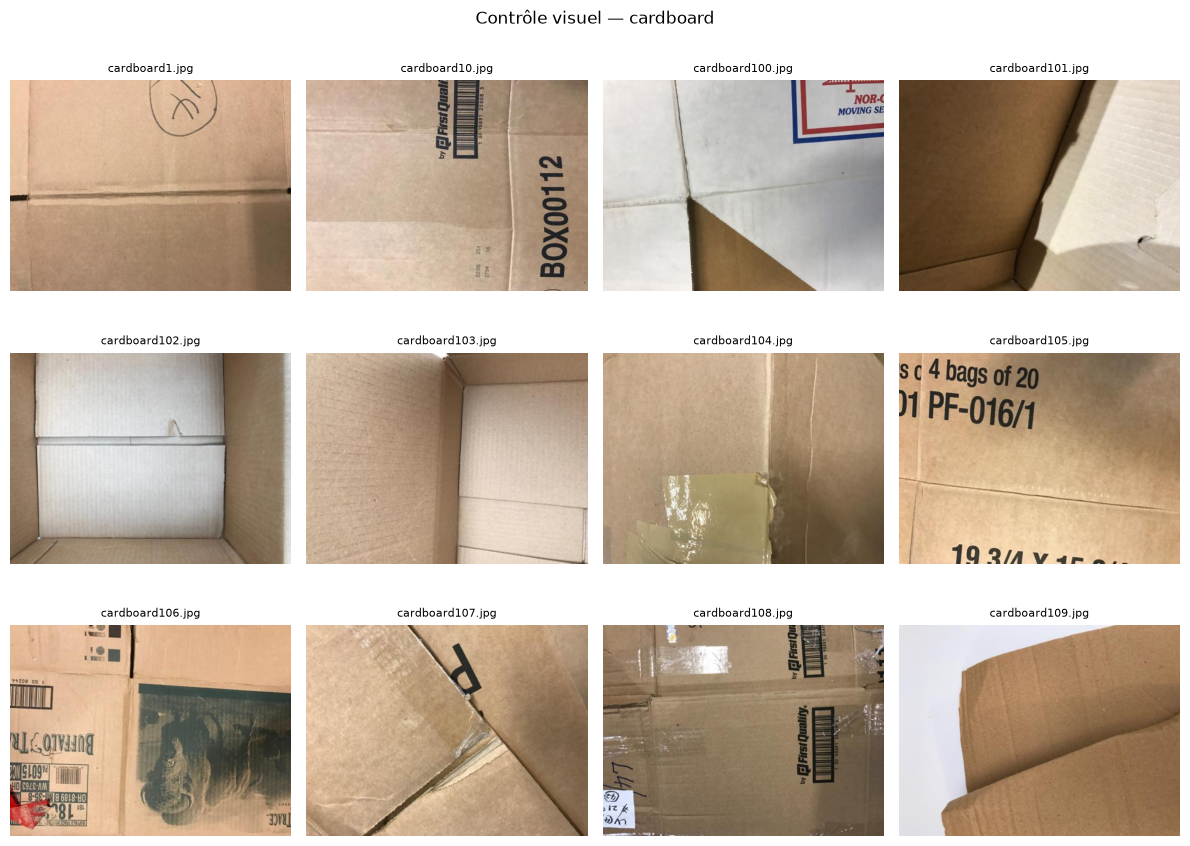

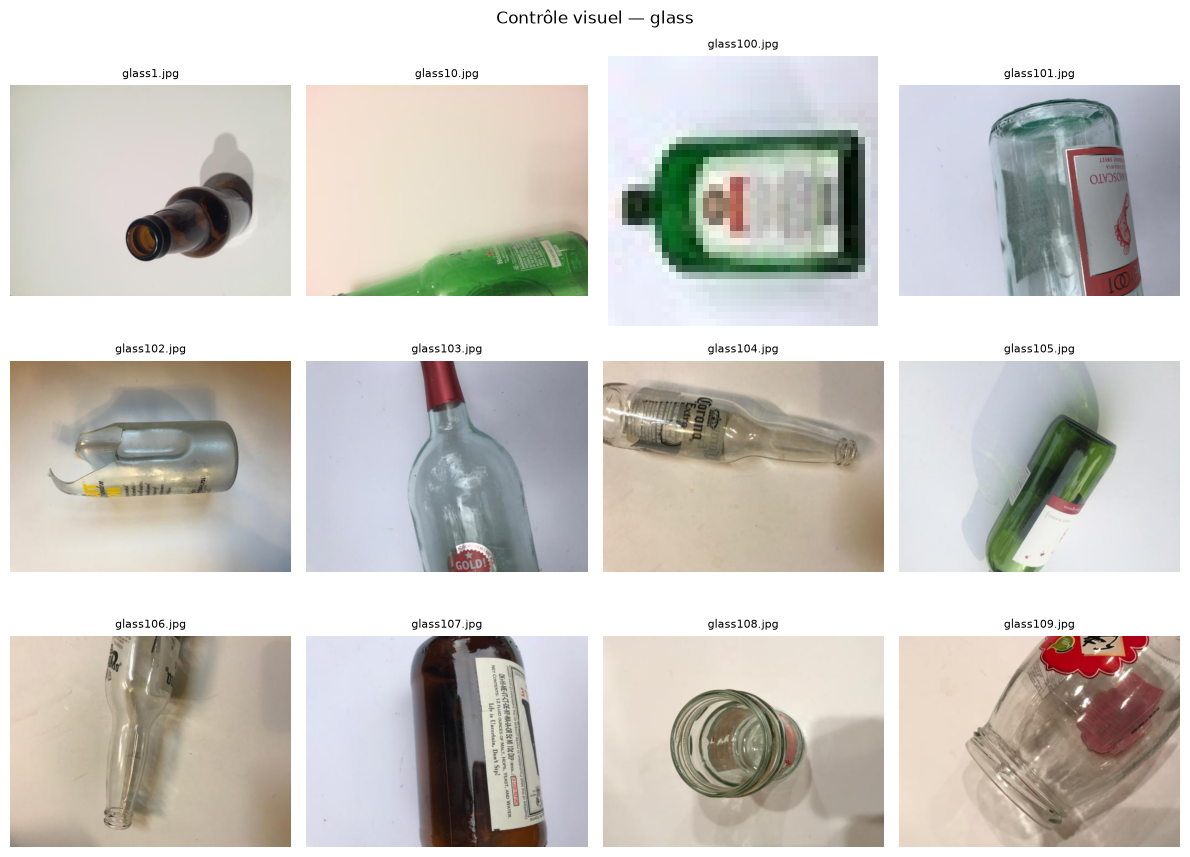

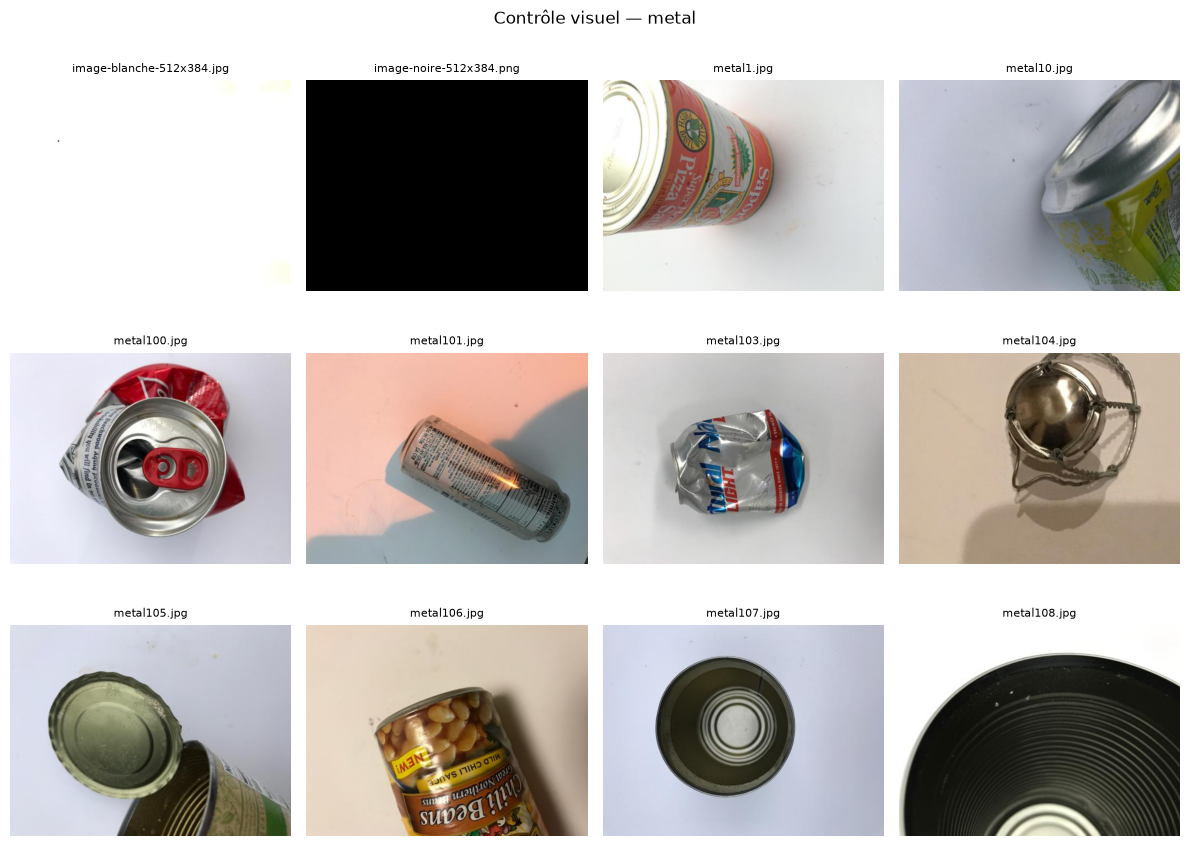

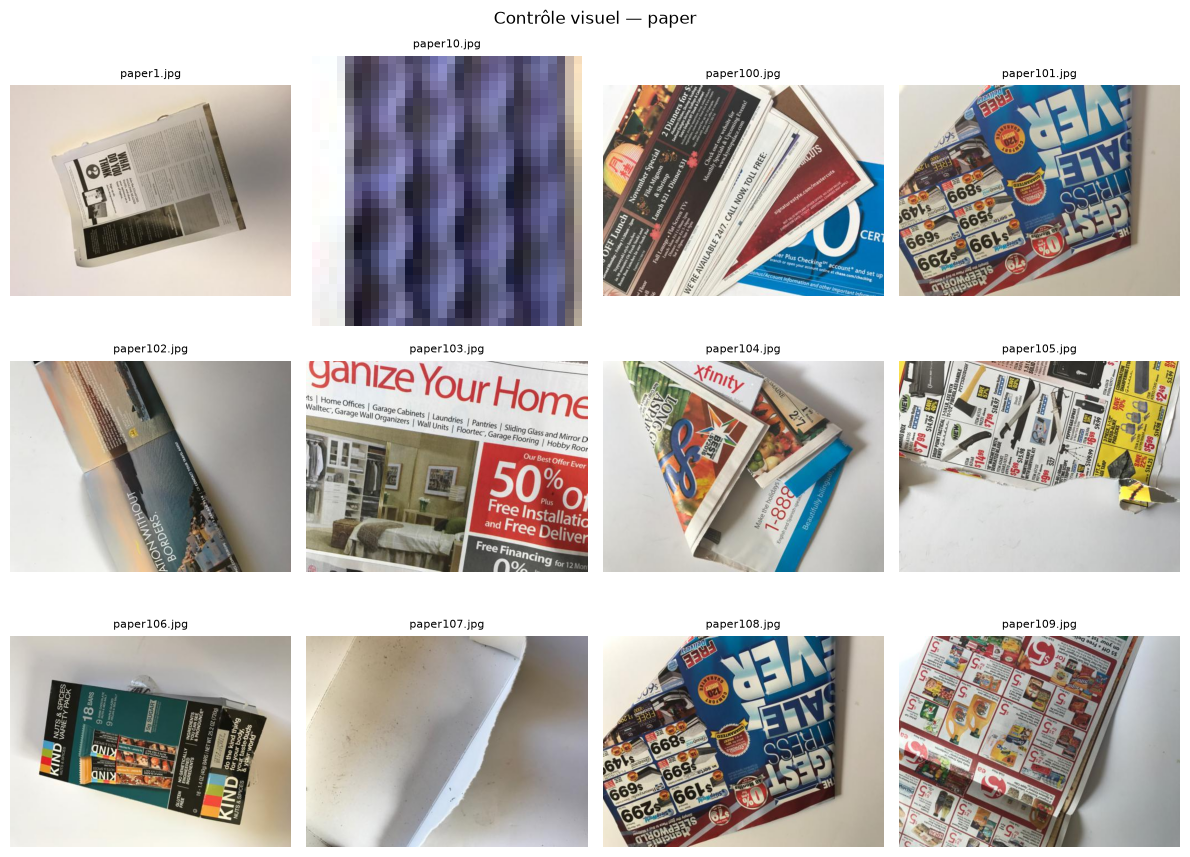

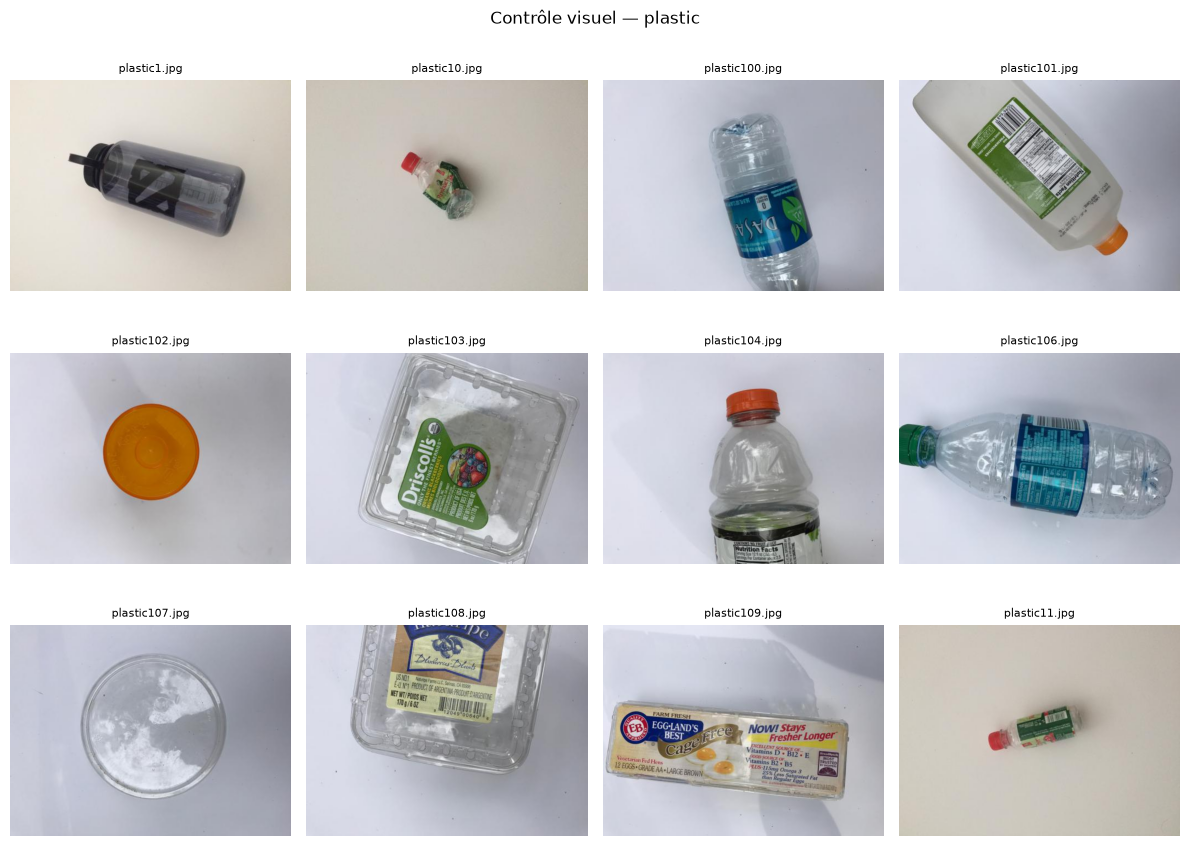

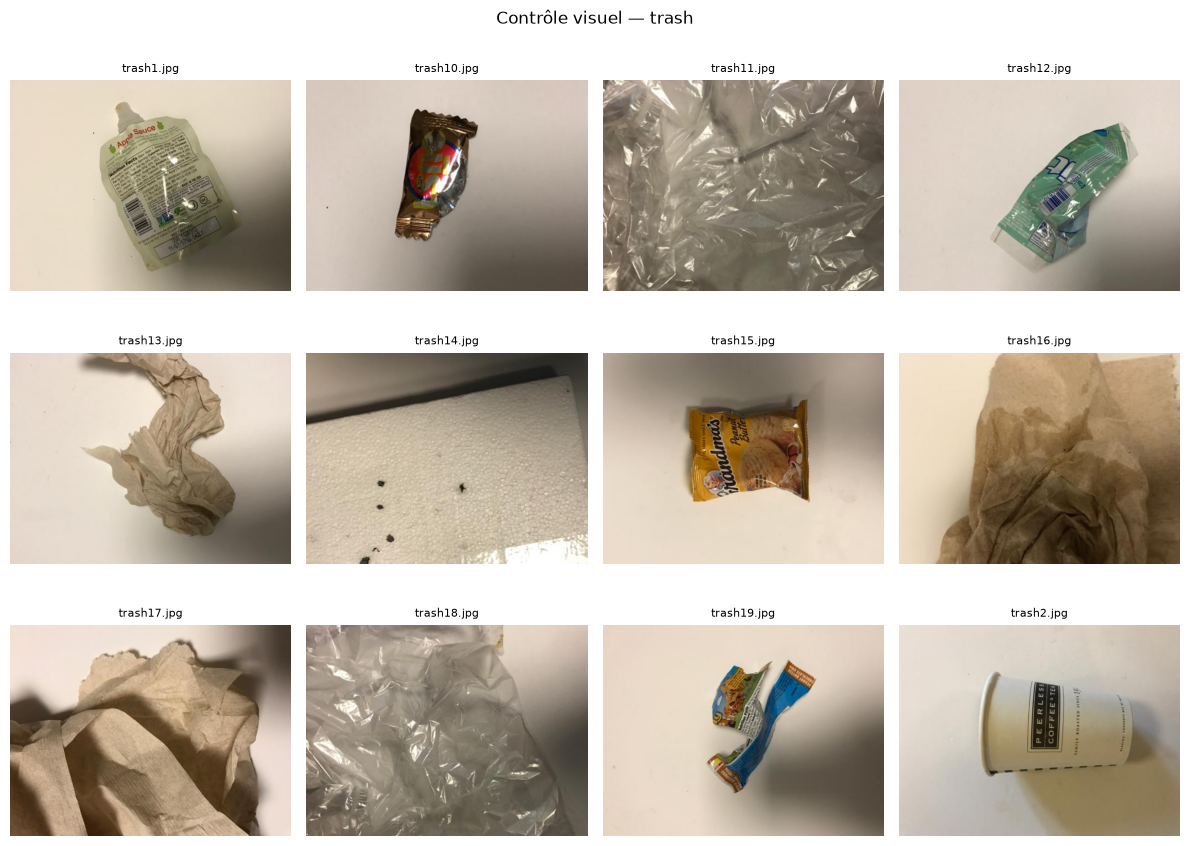

In [37]:
for classe in CLASSES:
    afficher_images_classe(classe)

### 8 : Compter les images pour analyser le déséquilibre des classes

Nous comptons le nombre d'images valides présentes dans chaque classe.

Cette information permet d'identifier la classe minoritaire qui pourra
ensuite bénéficier de la data augmentation.

In [38]:
nombre_par_classe = (
    df_images[~df_images["corrompue"]]
    .groupby("classe")
    .size()
    .sort_values()
)

nombre_par_classe

classe
trash         49
metal        148
cardboard    168
glass        187
plastic      223
paper        251
dtype: int64

In [39]:
# un rendu plus ergonomique 

print("Nombre d'images par classe :")

for classe, nombre in nombre_par_classe.items():
    print(f"{classe}: {nombre}")

Nombre d'images par classe :
trash: 49
metal: 148
cardboard: 168
glass: 187
plastic: 223
paper: 251


In [40]:
# identifier la classe minoritaire et celle majoritaire

classe_min = nombre_par_classe.idxmin()
nombre_min = nombre_par_classe.min()

classe_max = nombre_par_classe.idxmax()
nombre_max = nombre_par_classe.max()

print(f"Classe minoritaire : {classe_min} ({nombre_min} images)")
print(f"Classe majoritaire : {classe_max} ({nombre_max} images)")

Classe minoritaire : trash (49 images)
Classe majoritaire : paper (251 images)


### 9.1 : Créer le redimensionnement avec padding

Toutes les images seront converties vers une taille de `224 × 224`.

Les proportions originales sont conservées. Lorsque les proportions ne
permettent pas d'occuper exactement le carré, un padding est ajouté.

In [41]:
from PIL import ImageOps


TAILLE_IMAGE = (224, 224)


def redimensionner_avec_padding(image, taille=TAILLE_IMAGE):
    """Redimensionne une image en conservant ses proportions."""
    
    image = image.copy()
    image.thumbnail(taille, Image.Resampling.LANCZOS)

    canvas = Image.new(
        "RGB",
        taille,
        color=(0, 0, 0)
    )

    x = (taille[0] - image.width) // 2
    y = (taille[1] - image.height) // 2

    canvas.paste(image, (x, y))

    return canvas

### 9.2 : Créer cleaned/

In [42]:
CLEANED_DIR = Path("../data/cleaned")

for classe in CLASSES:
    (CLEANED_DIR / classe).mkdir(parents=True, exist_ok=True)

### 9.3 : Redimensionner les images dans le dataset nettoyé

Les images valides du dataset original sont copiées dans `cleaned/` après
redimensionnement.

Le dossier `raw/` n'est jamais modifié.

In [43]:
for _, ligne in df_images.iterrows():

    if ligne["corrompue"]:
        continue

    with Image.open(ligne["chemin"]) as image:
        image_rgb = image.convert("RGB")
        image_cleaned = redimensionner_avec_padding(image_rgb)

    destination = CLEANED_DIR / ligne["classe"] / ligne["nom"]
    image_cleaned.save(destination)

In [44]:
# verif

chemins_cleaned = list(CLEANED_DIR.glob("*/*"))

print(f"Images nettoyées : {len(chemins_cleaned)}")

Images nettoyées : 1026


In [45]:
# verifier l'image [0] de cleaned

image_test = Image.open(chemins_cleaned[0])

print(image_test.size)
print(image_test.mode)

(224, 224)
RGB


### 10 : Vérifier les modes pour uniformisation

Toutes les images du dataset nettoyé doivent être au format RGB.

Le mode RGB correspond à trois canaux : rouge, vert et bleu.

In [46]:
modes_cleaned = {}

for chemin in chemins_cleaned:
    with Image.open(chemin) as image:
        modes_cleaned[image.mode] = modes_cleaned.get(image.mode, 0) + 1

modes_cleaned

{'RGB': 1024, 'P': 2}

### 11 : Créer une fonction de normalisation pour la mise à l'échelle des pixels 

Les images RGB utilisent des valeurs de pixels comprises entre `0` et `255`.

Nous les convertissons en nombres flottants compris entre `0` et `1` afin
de faciliter leur utilisation par un modèle de Machine Learning ou de Deep Learning.

In [47]:
# fonction pour normaliser

def normaliser_pixels(image):
    """Convertit les pixels de [0, 255] vers [0, 1]."""
    
    pixels = np.asarray(image, dtype=np.float32)

    return pixels / 255.0

In [48]:
# test

with Image.open(chemins_cleaned[0]) as image:
    pixels_normalises = normaliser_pixels(image)

print("Minimum :", pixels_normalises.min())
print("Maximum :", pixels_normalises.max())
print("Type :", pixels_normalises.dtype)

Minimum : 0.0
Maximum : 1.0
Type : float32


### 12.1 : Préparer le découpage Train / Validation / Test

Le dataset nettoyé est séparé en trois ensembles :

- `train` : 70 %
- `validation` : 15 %
- `test` : 15 %

Ces proportions constituent un choix d'implémentation.

note : Le découpage est réalisé avant toute data augmentation.

In [49]:
import shutil

from sklearn.model_selection import train_test_split

In [50]:
# creer le dossier split

SPLIT_DIR = Path("../data/split")

for ensemble in ["train", "validation", "test"]:
    for classe in CLASSES:
        (SPLIT_DIR / ensemble / classe).mkdir(
            parents=True,
            exist_ok=True
        )

### 12.2 : Découper chaque classe

On garde les classes équilibrées dans chaque sous-ensemble grâce à un découpage par classe.

In [51]:
for classe in CLASSES:

    images = sorted((CLEANED_DIR / classe).glob("*"))

    train, reste = train_test_split(
        images,
        test_size=0.30,
        random_state=42
    )

    validation, test = train_test_split(
        reste,
        test_size=0.50,
        random_state=42
    )

    for image in train:
        shutil.copy2(image, SPLIT_DIR / "train" / classe / image.name)

    for image in validation:
        shutil.copy2(
            image,
            SPLIT_DIR / "validation" / classe / image.name
        )

    for image in test:
        shutil.copy2(image, SPLIT_DIR / "test" / classe / image.name)

In [52]:
# verif

for ensemble in ["train", "validation", "test"]:

    print(f"\n{ensemble.upper()}")

    for classe in CLASSES:
        nombre = len(list((SPLIT_DIR / ensemble / classe).glob("*")))
        print(f"{classe}: {nombre}")


TRAIN
cardboard: 117
glass: 130
metal: 103
paper: 175
plastic: 156
trash: 175

VALIDATION
cardboard: 25
glass: 28
metal: 22
paper: 38
plastic: 33
trash: 7

TEST
cardboard: 26
glass: 29
metal: 23
paper: 38
plastic: 34
trash: 8


### 13.1 : Identifier la classe minoritaire dans train pour la Data Augmentation

La data augmentation est appliquée uniquement à la classe minoritaire
et uniquement sur le dataset d'entraînement.

Les ensembles validation et test ne sont pas augmentés.

In [53]:
train_counts = {}

for classe in CLASSES:
    train_counts[classe] = len(
        list((SPLIT_DIR / "train" / classe).glob("*"))
    )

train_counts

{'cardboard': 117,
 'glass': 130,
 'metal': 103,
 'paper': 175,
 'plastic': 156,
 'trash': 175}

In [54]:
# print min & max

classe_minoritaire = min(
    train_counts,
    key=train_counts.get
)

classe_majoritaire = max(
    train_counts,
    key=train_counts.get
)

print("Classe minoritaire :", classe_minoritaire)
print("Classe majoritaire :", classe_majoritaire)

Classe minoritaire : metal
Classe majoritaire : paper


### 13.2 : Créer les transformations Keras

La data augmentation utilise plusieurs transformations légères :

- retournement horizontal ;
- rotation ;
- zoom ;
- translation ;
- luminosité ;
- contraste ;
- variation légère de couleur.

Les transformations sont volontairement modérées afin de conserver
le sens de l'image.

In [55]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [56]:
import tensorflow as tf
from tensorflow import keras

print(tf.__version__)

2.21.0


In [57]:
augmentation = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.08),
        keras.layers.RandomZoom(0.10),
        keras.layers.RandomTranslation(0.10, 0.10),
        keras.layers.RandomBrightness(0.10),
        keras.layers.RandomContrast(0.10),
        keras.layers.RandomHue(0.05),
    ],
    name="data_augmentation"
)

### 13.3 : Générer des images augmentées

Nous générons des variantes uniquement à partir des images de la classe
minoritaire du jeu d'entraînement.

Les images originales sont conservées.

In [58]:
classe_dir = SPLIT_DIR / "train" / classe_minoritaire

images_minoritaires = sorted(classe_dir.glob("*"))

nombre_a_ajouter = (
    train_counts[classe_majoritaire]
    - train_counts[classe_minoritaire]
)

print(f"Images à générer : {nombre_a_ajouter}")

Images à générer : 72


In [59]:
for index in range(nombre_a_ajouter):

    source = images_minoritaires[index % len(images_minoritaires)]

    image = keras.utils.load_img(
        source,
        target_size=(224, 224)
    )

    tableau = keras.utils.img_to_array(image)
    tableau = tf.expand_dims(tableau, axis=0)

    image_aug = augmentation(tableau, training=True)
    image_aug = tf.cast(
        tf.clip_by_value(image_aug[0], 0, 255),
        tf.uint8
    )

    destination = (
        classe_dir
        / f"augmented_{index:05d}.jpg"
    )

    keras.utils.save_img(destination, image_aug)

In [ ]:
# verif 

nombre_final = len(list(classe_dir.glob("*")))

print(
    f"{classe_minoritaire} : "
    f"{nombre_final} images après augmentation"
)

metal : 175 images après augmentation


In [61]:
assert nombre_final >= train_counts[classe_majoritaire]

### 13.4 : Pourquoi augmenter après le découpage ?

La data augmentation doit être appliquée uniquement au jeu d'entraînement.

Si elle était réalisée avant le découpage, une image originale pourrait
produire plusieurs variantes très similaires.

Une variante pourrait alors se retrouver dans `train` tandis qu'une autre
se retrouverait dans `validation` ou `test`.

Le modèle aurait alors déjà vu une image presque identique pendant son
entraînement : cela créerait une fuite de données et rendrait l'évaluation
moins fiable.

La règle est donc :

raw → nettoyage → train/validation/test → augmentation uniquement sur train

### 14 : Bonus : rapport d'audit

Un rapport CSV est généré afin de conserver une synthèse de l'état du dataset.

Ce rapport permet de retrouver rapidement les principaux problèmes détectés
pendant l'exploration sans devoir parcourir manuellement le notebook.

In [64]:
AUDIT_DIR = Path("../reports")
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

nombre_doublons = (
    df_images["hash_image"].notna()
    & df_images["hash_image"].duplicated(keep=False)
).sum()

rapport_audit = pd.DataFrame(
    {
        "indicateur": [
            "total d'images",
            "images corrompues",
            "images quasi vides",
            "images trop petites",
            "doublons",
            "images grayscale",
            "images rgba",
            "images mal classees",
        ],
        "nombre": [
            len(df_images),
            int(df_images["corrompue"].sum()),
            int(df_images["vide"].sum()),
            int(df_images["trop_petite"].sum()),
            nombre_doublons,
            int((df_images["nombre_canaux"] == 1).sum()),
            int((df_images["nombre_canaux"] == 4).sum()),
            "controle visuel",
        ],
    }
)

rapport_audit

,indicateur,nombre
0,total d'images,1032
1,images corrompues,6
2,images quasi vides,4
3,images trop petites,13
4,doublons,30
5,images grayscale,2
6,images rgba,18
7,images mal classees,controle visuel


In [ ]:
# sauvegarde

rapport_audit.to_csv(
    AUDIT_DIR / "audit_images.csv",
    index=False
)

In [ ]:
# verif

rapport = pd.read_csv(AUDIT_DIR / "audit_images.csv")

rapport

,indicateur,nombre
0,total d'images,1032
1,images corrompues,6
2,images quasi vides,4
3,images trop petites,13
4,doublons,30
5,images grayscale,2
6,images rgba,18
7,images mal classees,controle visuel
